## Sea Slugs time series data
This notebook demonstrates how to cluster the Sea Slugs time series data via hierarchical Hakwes functions (HHF) with scaled exponential excitation and inhibition functions (with and without delayed response to inputs). First, we import the data:

In [1]:
import numpy as np
## Import csv
X = np.loadtxt('../data/time_series.csv', delimiter=',', skiprows=1, dtype=object)
## Remove first two columns
X = X[:, 2:]
## Convert to float
X = X.astype(np.float64)

The *Python* functions used to fit the HHF are all in the package `hierarchical_hawkes`. Instructions for installation can be found in the main `README` file for this repository. 

In [2]:
import hierarchical_hawkes as hhf

For plotting, we use `matplotlib` with LaTeX rendering via `tikz` for high-quality figures. Lines 3 and 4 in the following code block configure LaTeX rendering with Times font. These lines can be removed if standard matplotlib rendering is preferred; in that case, only `import matplotlib.pyplot as plt` is required.

In [3]:
import matplotlib.pyplot as plt
## Compile with tikz and times font
plt.rc('text', usetex=True)
plt.rc('font', family='times')

First, we plot all time series and their average:

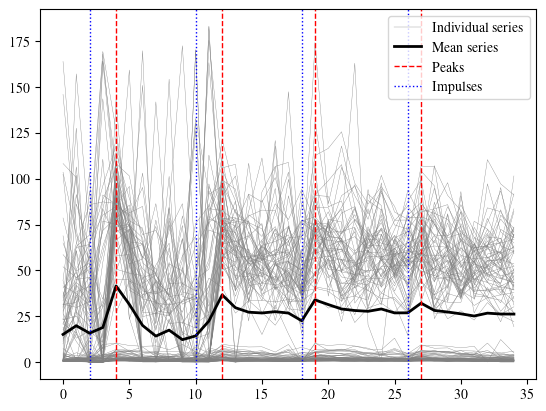

In [4]:
plt.plot(X.T, markersize=2, linewidth=0.25, c='gray', label='_nolegend_')
# Add one proxy line for legend
plt.plot([], [], c='gray', linewidth=0.25, label='Individual series')
plt.plot(X.mean(axis=0), markersize=2, linewidth=2, c='black', label='Mean series')
for i, jump in enumerate([4, 12, 19, 27]):
    label = 'Peaks' if i == 0 else None
    plt.axvline(x=jump, color='red', linestyle='--', linewidth=1, label=label)
for i, jump in enumerate([2, 10, 18, 26]):
    label = 'Impulses' if i == 0 else None
    plt.axvline(x=jump, color='blue', linestyle='dotted', linewidth=1, label=label)
plt.legend()
plt.show()

Zooming in on the average time series, we can see jumps more clearly:

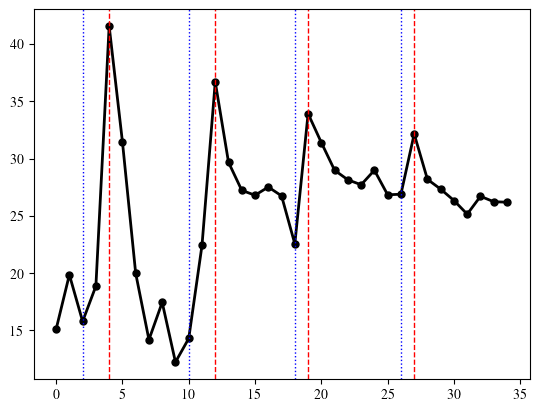

In [5]:
plt.plot(X.mean(axis=0), markersize=5, linewidth=2, c='black', marker='o')
for i, jump in enumerate([4, 12, 19, 27]):
    label = 'Peaks' if i == 0 else None
    plt.axvline(x=jump, color='red', linestyle='--', linewidth=1, label=label)
for i, jump in enumerate([2, 10, 18, 26]):
    label = 'Impulses' if i == 0 else None
    plt.axvline(x=jump, color='blue', linestyle='dotted', linewidth=1, label=label)
plt.show()

Set up clustering of curves via the hierarchical Hawkes model (with delay) with given impulses for $K=5$, initialised via $k$-means.

In [6]:
K = 5
model = hhf.HierarchicalHakwesMixtureEM(K=K, fit_fn=hhf.fit_process, predict_fn=hhf.calculate_intensity, 
                                        jumps=np.array([ 2, 10, 18, 26]), jumps_alpha=np.array([ 4, 12, 19, 27]), 
                                        delay=True, max_iter=200, tol=1e-7, verbose=False)

Similarly, set up clustering of curves via the hierarchical Hawkes model (without delay) with given impulses for $K=5$, initialised via $k$-means.

In [7]:
model_no_delay = hhf.HierarchicalHakwesMixtureEM(K=K, fit_fn=hhf.fit_process, predict_fn=hhf.calculate_intensity, 
                                        jumps=np.array([ 4, 12, 19, 27]), 
                                        delay=False, max_iter=200, tol=1e-7, verbose=False)

In [8]:
import numpy as np
max_ll = -np.inf
max_ll_no_delay = -np.inf
for j, random_state in enumerate([42, 171, 256, 512, 1024, 2048, 4096, 8192, 2025, 1234]):
    print(f'Random state: {random_state}')
    model.fit(X, init_method='kmeans', random_state=random_state)
    if model.loglik_trace[-1] > max_ll:
        max_ll = model.loglik_trace[-1]
        random_state_best = random_state
    model_no_delay.fit(X, init_method='kmeans', random_state=random_state)
    if model_no_delay.loglik_trace[-1] > max_ll_no_delay:
        max_ll_no_delay = model_no_delay.loglik_trace[-1]
        random_state_best_no_delay = random_state

Random state: 42
Random state: 171
Random state: 256
Random state: 512
Random state: 1024


/Users/fraspass/Documents/github/hierarchical_hawkes/lib/hierarchical_hawkes/mixture.py:202: RuntimeWarning: divide by zero encountered in log
  params = np.log(list(np.exp(result_init.x)) + [1.5, 0.5, 0.25])
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:507: RuntimeWarning: invalid value encountered in subtract
  dx = ((x0 + h) - x0)
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/scipy/optimize/_numdiff.py:595: RuntimeWarning: invalid value encountered in scalar subtract
  dx = x1[i] - x0[i]  # Recompute dx as exactly representable number.


Random state: 2048
Random state: 4096
Random state: 8192
Random state: 2025
Random state: 1234


Refit the model to obtain the parameters corresponding to the highest log-likelihood:

In [9]:
model.fit(X, init_method='kmeans', random_state=random_state_best)
model_no_delay.fit(X, init_method='kmeans', random_state=random_state_best_no_delay)

Calculate cluster allocations via the E-step of the EM algorithm:

In [10]:
z1 = model.E_step(X)[0].argmax(axis=1)
z2 = model_no_delay.E_step(X)[0].argmax(axis=1)

In [11]:
from collections import Counter
Counter(z1), Counter(z2)

(Counter({np.int64(0): 44,
          np.int64(3): 38,
          np.int64(1): 24,
          np.int64(2): 16,
          np.int64(4): 5}),
 Counter({np.int64(1): 44,
          np.int64(3): 34,
          np.int64(0): 24,
          np.int64(4): 14,
          np.int64(2): 11}))

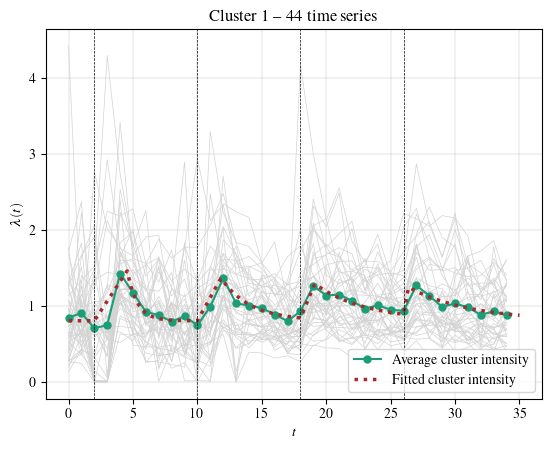

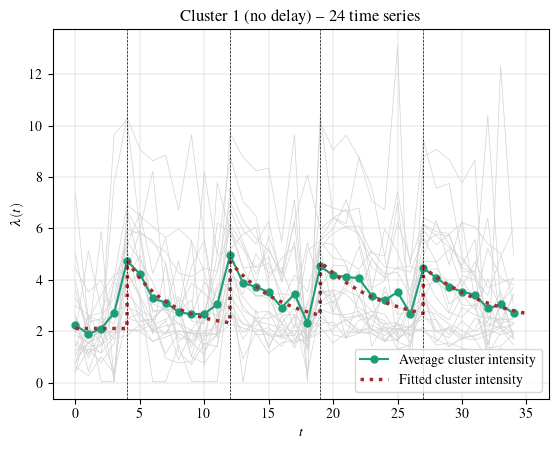

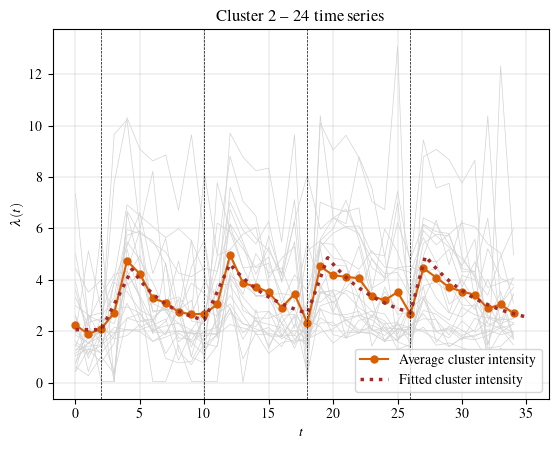

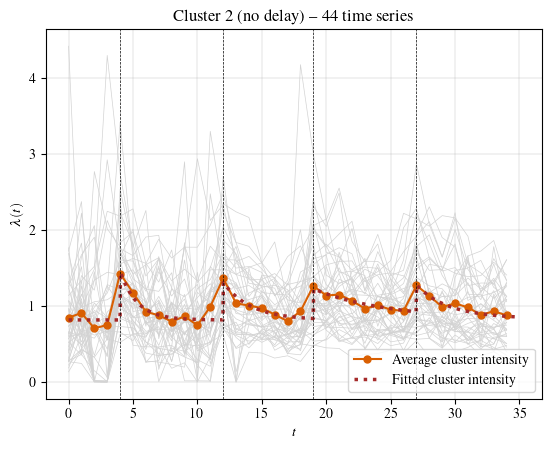

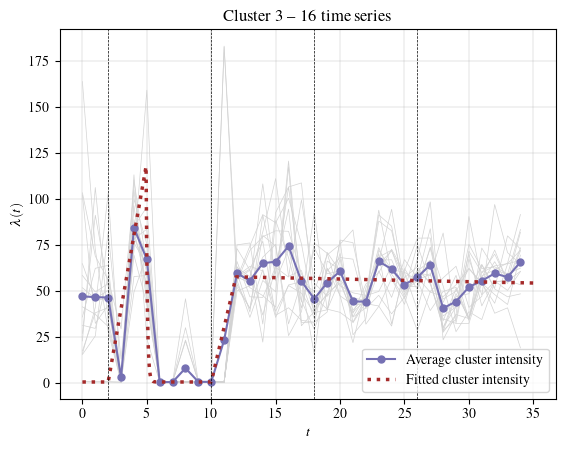

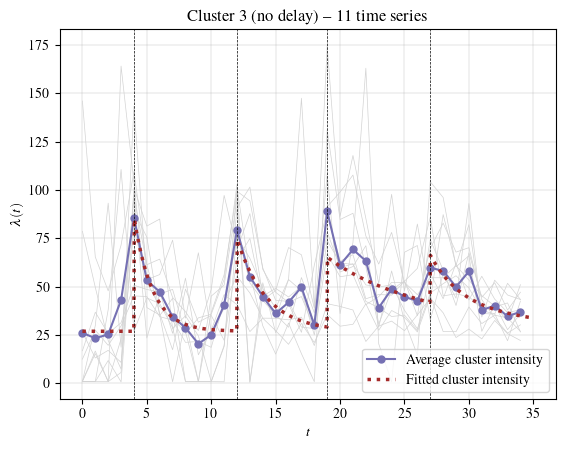

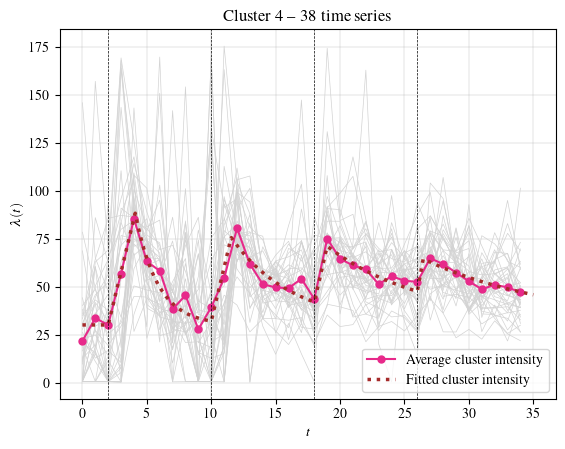

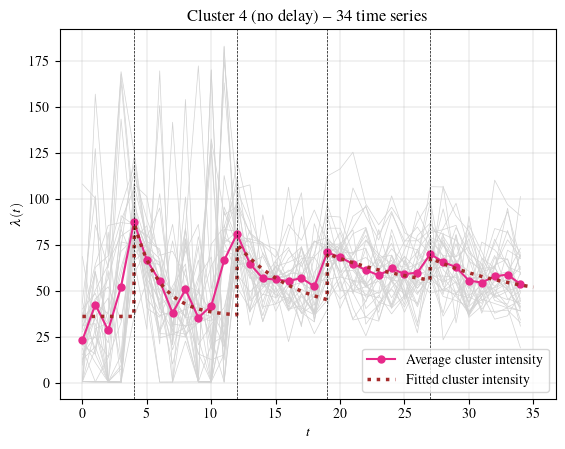

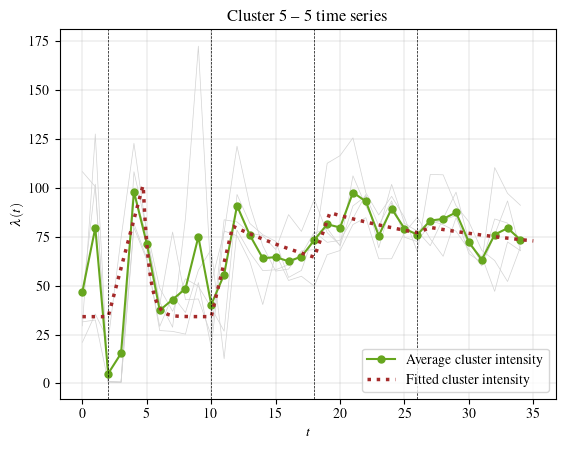

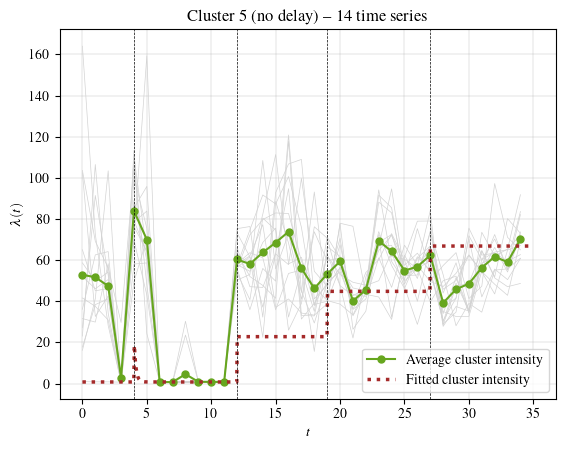

In [21]:
## Colour palette
colors = plt.get_cmap('Dark2').colors
n, T = X.shape
time_grid = np.linspace(0, T, 1000)
for ell in range(K):
    ## Plot for cluster ell for both models
    Xlm = X[z1 == ell].mean(axis=0)
    ints = hhf.calculate_intensity(model.theta[ell], time_grid, model.jumps)
    ints_no_delay = hhf.calculate_intensity(model_no_delay.theta[ell], time_grid, model_no_delay.jumps)
    for i in range(n):
        if z1[i] == ell:
            plt.plot(np.arange(T), X[i], linewidth=0.5, c='lightgray')
    ## Plot the optimized intensity function
    plt.plot(Xlm, color=colors[ell], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster intensity')
    plt.plot(time_grid, ints, color='brown', linewidth=2.5, ls='dotted', label='Fitted cluster intensity')
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\lambda(t)$')
    for jump in model.jumps:
        plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
    plt.legend(loc='lower right')
    ## plt.ylim(0, np.max(ints) + np.max(ints) / 10)
    plt.grid(linewidth=0.25)
    plt.title(f'Cluster {ell+1} -- {np.sum(z1 == ell)} time series')
    plt.savefig(f'../figures/sea_slugs/hhf_cluster_{ell}.pdf', bbox_inches='tight')
    plt.show(block=False)
    ## Repeat for no-delay model
    Xlm = X[z2 == ell].mean(axis=0)
    for i in range(n):
        if z2[i] == ell:
            plt.plot(np.arange(T), X[i], linewidth=0.5, c='lightgray')
    plt.plot(Xlm, color=colors[ell], linewidth=1.5, marker='o', markersize=5,
             label='Average cluster intensity')
    plt.plot(time_grid, ints_no_delay, color='brown', linewidth=2.5, ls='dotted', label='Fitted cluster intensity')
    plt.xlabel(r'$t$')
    plt.ylabel(r'$\lambda(t)$')
    for jump in model_no_delay.jumps:
        plt.axvline(x=jump, color='black', linestyle='--', linewidth=0.5)
    plt.legend(loc='lower right')
    ## plt.ylim(0, np.max(ints_no_delay) + np.max(ints_no_delay) / 10)
    plt.grid(linewidth=0.25)
    plt.title(f'Cluster {ell+1} (no delay) -- {np.sum(z2 == ell)} time series')
    plt.savefig(f'../figures/sea_slugs/hhf_no_delay_cluster_{ell}.pdf', bbox_inches='tight')
    plt.show(block=False)
    